In [1]:
import pickle, sys
import pandas as pd
sys.path.append('..')

from models.path_finder import find_journey

with open('../models/mood_graph.pkl', 'rb') as f:
    G = pickle.load(f)

candidates = find_journey(G, 0.15, 0.20, 0.85, 0.80, n_songs=10)
print(f'{len(candidates)} candidate songs:')
for c in candidates:
    print(f"  {c['name'][:38]:38s} val={c['valence']:.2f} nrg={c['energy']:.2f}")

10 candidate songs:
  Shor                                   val=0.16 nrg=0.20
  Aararo                                 val=0.19 nrg=0.22
  Lost Boy                               val=0.22 nrg=0.26
  Pal Pal Dil Ke Paas - Unwind Instrumen val=0.24 nrg=0.28
  Muskurane - Lofi Flip                  val=0.26 nrg=0.31
  Kahaani                                val=0.27 nrg=0.33
  What Is Love                           val=0.30 nrg=0.36
  Kitaab                                 val=0.33 nrg=0.38
  Dil Beparvah - The Dewarists, Season 5 val=0.35 nrg=0.39
  Tera Hua Na Mai Kabhi VIP              val=0.36 nrg=0.40


In [2]:
from models.rl_agent import train_rl_agent

# Watch ep_rew_mean in logs — should trend upward toward 0
model = train_rl_agent(
    candidates  = candidates,
    target_mood = (0.85, 0.80),
    timesteps   = 50_000,
    save_path   = '../models/ppo_mood_agent'
)
print('Training complete!')

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 10       |
|    ep_rew_mean     | -5.19    |
| time/              |          |
|    fps             | 2205     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 512      |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 10          |
|    ep_rew_mean          | -5.15       |
| time/                   |             |
|    fps                  | 1508        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.012430653 |
|    clip_fraction        | 0.0828      |
|    clip_range           | 0.2         |
|    entropy_loss   

Mean arc deviation (lower = smoother):
  RL Agent (PPO)        : 0.4807
  Greedy (sort)         : 0.4207
  Random baseline       : 0.5437


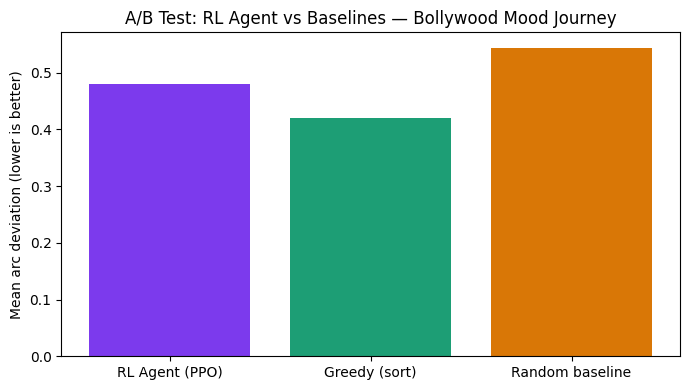

Chart saved to data/ab_test.png


In [3]:
import random
import matplotlib.pyplot as plt
from models.rl_agent import get_rl_ordered_playlist

TARGET = (0.85, 0.80)

def arc_deviation(playlist, target):
    n  = len(playlist)
    sv = playlist[0]['valence']
    se = playlist[0]['energy']
    tv, te = target
    total  = 0
    for i, s in enumerate(playlist):
        p      = i / max(n - 1, 1)
        total += abs(s['valence'] - (sv + p * (tv - sv)))
        total += abs(s['energy']  - (se + p * (te - se)))
    return total / n

rl_order     = get_rl_ordered_playlist(candidates, TARGET, '../models/ppo_mood_agent')
greedy_order = sorted(candidates, key=lambda s: s['valence'] + s['energy'])
random_order = random.sample(candidates, len(candidates))

results = {
    'RL Agent (PPO)':  arc_deviation(rl_order,     TARGET),
    'Greedy (sort)':   arc_deviation(greedy_order, TARGET),
    'Random baseline': arc_deviation(random_order, TARGET),
}

print('Mean arc deviation (lower = smoother):')
for algo, score in results.items():
    print(f'  {algo:22s}: {score:.4f}')

plt.figure(figsize=(7, 4))
plt.bar(results.keys(), results.values(),
        color=['#7C3AED', '#1D9E75', '#D97706'])
plt.ylabel('Mean arc deviation (lower is better)')
plt.title('A/B Test: RL Agent vs Baselines — Bollywood Mood Journey')
plt.tight_layout()
plt.savefig('../data/ab_test.png', dpi=150)
plt.show()
print('Chart saved to data/ab_test.png')